In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.integrate as integrate
from scipy.special import erf

import analysis.utils as utils # here's rate calculation functions
import analysis.plotter as plotter
import analysis.config as config

from scipy.special import spherical_jn

In [2]:
N0 = 6.02e26
sigma_pb = 1e-1 #pb
sigma_n = sigma_pb * 1e-40 #m2
rho_D = 7.13e-22 # SI
A = 28
M_T = A*0.932 * 1.78e-27 #SI = GeV * 1.78e-27
M_D = 1 * 1.78e-27
mu_n = M_T*M_D/(M_T+M_D)

In [32]:
def nuclear_form_factor(E_R_KeV, M_T = M_T, A = A):
    E_R_SI = E_R_KeV * 1.6e-16
    q = np.sqrt(2*M_T*E_R_SI)
    r_n = 1.14 * A**(1/3) *1e-15 #m
    s = 0.9 *1e-15 #m
    F = 3 * spherical_jn(1, q*r_n)/(q*r_n)*np.exp(-(q*s)**2/2)
    print(q)
    print((q*r_n))
    print(spherical_jn(1, q*r_n))
    print(np.exp(-(q*s)**2/2))
    return F

In [33]:
nuclear_form_factor(50)**2

2.726195297479621e-20
9.437301416076735e-35
3.145767138692277e-35
1.0


1.0000000000000204

In [ ]:
def velo_int(E_R, v_0, v_E, v_esc):
    # get normalization factor k 
    E_R_SI = E_R *1.6e-16
    prefactor = np.pi**(1.5) * v_0**3
    term1 = erf(v_esc / v_0)
    term2 = (2 * v_esc / (np.sqrt(np.pi) * v_0)) * np.exp(-v_esc**2 / v_0**2)
    inverse_k = prefactor * (term1 - term2)
    k =  1 / inverse_k
    
    v_min = np.sqrt(M_T*E_R_SI/2/mu_n**2)
    
    prefactor2 = (np.pi**1.5 * v_0**3 * k) / (2 * v_E)
    v_min = np.asarray(v_min)  # ensure array-like for masking
    eta_val = np.zeros_like(v_min)

    # Case 1: v_min <= v_esc - v_E
    mask1 = v_min <= (v_esc - v_E)
    eta_val[mask1] = (
        erf((v_E - v_min[mask1]) / v_0) +
        erf((v_E + v_min[mask1]) / v_0) -
        (4 * v_E / (np.sqrt(np.pi) * v_0)) *
        np.exp(-v_esc**2 / v_0**2)
    )

    # Case 2: v_esc - v_E < v_min <= v_esc + v_E
    mask2 = ((v_min > (v_esc - v_E)) & (v_min <= (v_esc + v_E)))
    eta_val[mask2] = (
        erf((v_E - v_min[mask2]) / v_0) +
        erf(v_esc / v_0) -
        (2 * (v_E + v_esc - v_min[mask2]) / (np.sqrt(np.pi) * v_0)) *
        np.exp(-v_esc**2 / v_0**2)
    )

    # Case 3: v_min > v_esc + v_E -> already zero

    return prefactor2 * eta_val
   

In [128]:
def get_rate_ben(E_KeV, M_D = M_D, xs = sigma_n):
    rate_SI = (N0 * sigma_n *rho_D *M_T)/(2*A*mu_n**2*M_D)*A**2*nuclear_form_factor(E_KeV)**2*velo_int(E_KeV, v_0=250e3, v_E=263e3, v_esc = 544e3)
    seconds_per_day = 24*3600
    keV_to_J = 1.6e-16
    return rate_SI * seconds_per_day * keV_to_J

In [129]:
E_Rs_KeV = np.linspace(0.001, 1.2, 10)
dRsben = [get_rate_ben(E) for E in E_Rs_KeV]

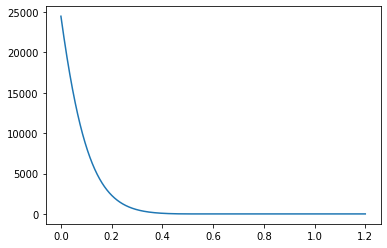

In [ ]:
E_Rs_KeV = np.linspace(0.0001, 1.2, 1000)
dRs0 = [get_rate_ben(E) for E in E_Rs_KeV]

plt.plot(E_Rs_KeV, dRs0)
